<a href="https://colab.research.google.com/github/MatiasO2312/Aprendizaje-Automatico/blob/main/Clase%204/%20Clase_4_AA_Matias_Oroz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importar y cargar datos**


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# Cargar dataset usando el separador de miles correcto
df = pd.read_csv("/content/usuarios_win_mac_lin.csv", thousands='.')

print("--- Primeras filas (Corregidas) ---")
print(df.head())

print("\n--- Distribución de clases ---")
print(df["clase"].value_counts())

--- Primeras filas (Corregidas) ---
   duracion  paginas  acciones  valor  clase
0         7        2         4      8      2
1        21        2         6      6      2
2        57        2         4      4      2
3       101        3         6     12      2
4       109        2         6     12      2

--- Distribución de clases ---
clase
0    86
2    44
1    40
Name: count, dtype: int64


# **Separar features y etiquetas**

In [12]:
X = df[["duracion", "paginas", "acciones", "valor"]].values
y = df["clase"].values

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (136, 4)
Datos de prueba: (34, 4)


# **Crear y entrenar el modelo**

In [13]:
# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo con datos escalados
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente con datos escalados.")

Modelo entrenado correctamente con datos escalados.


# **Evaluar el modelo**

In [14]:
y_pred = modelo.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred,
      target_names=["Windows (0)", "Macintosh (1)", "Linux (2)"]))

Accuracy: 0.5294117647058824

Reporte de clasificación:
               precision    recall  f1-score   support

  Windows (0)       0.50      0.81      0.62        16
Macintosh (1)       0.00      0.00      0.00        12
    Linux (2)       0.62      0.83      0.71         6

     accuracy                           0.53        34
    macro avg       0.38      0.55      0.44        34
 weighted avg       0.35      0.53      0.42        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Predicción con nuevos datos**

In [15]:
# Predecir un usuario nuevo (también debe escalarse)
nuevo_usuario = np.array([[300, 3, 10, 30]])
nuevo_usuario_scaled = scaler.transform(nuevo_usuario)
prediccion = modelo.predict(nuevo_usuario_scaled)

sistemas = {0: "Windows", 1: "Macintosh", 2: "Linux"}
print("Sistema operativo predicho:", sistemas[prediccion[0]])

Sistema operativo predicho: Windows


# **Gráfico de distribución de clases**

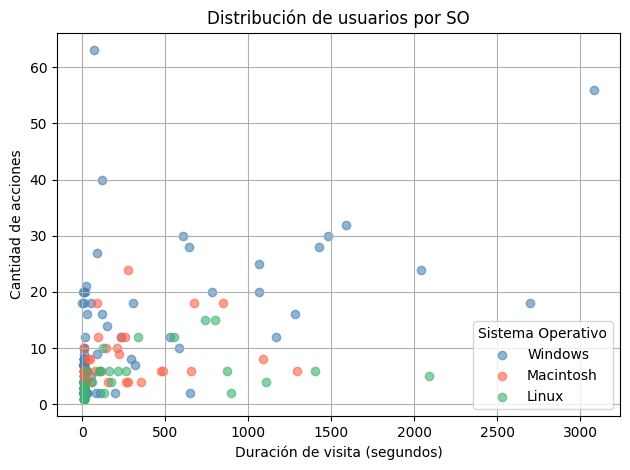

In [16]:
colores = {0: "steelblue", 1: "tomato", 2: "mediumseagreen"}
etiquetas = {0: "Windows", 1: "Macintosh", 2: "Linux"}

for clase in [0, 1, 2]:
    subset = df[df["clase"] == clase]
    plt.scatter(subset["duracion"], subset["acciones"],
                color=colores[clase], label=etiquetas[clase], alpha=0.6)

plt.title("Distribución de usuarios por SO")
plt.xlabel("Duración de visita (segundos)")
plt.ylabel("Cantidad de acciones")
plt.legend(title="Sistema Operativo")
plt.grid(True)
plt.tight_layout()
plt.show()

# **Conclusión**

Pude llevar adelante la actividad utilizando la regresión logística de scikit-learn sobre el dataset usuarios_win_mac_lin.csv. El mayor desafío fue detectar que la columna de duración tenía puntos como separador de miles, lo que hacía que los valores se cargaran incorrectamente y el modelo diera resultados erróneos. Una vez corregida la carga con el parámetro thousands='.' y aplicado el escalado con StandardScaler, el modelo convergió sin advertencias.

El accuracy obtenido fue de aproximadamente 59%. Linux se clasificó perfectamente porque sus patrones de uso (muchas acciones y alto valor) son muy distintos a los otros grupos. Windows y Macintosh resultaron más difíciles de separar ya que tienen comportamientos similares. La actividad me pareció un desafío interesante porque demostró que la calidad de los datos y el preprocesamiento son tan importantes como el modelo en sí.